# Ambrosini-style 1D stability map (baseline linear solver)

Этот ноутбук реализует **бэйзлайн-решатель** линейной устойчивости 1D сверхкритического течения в канале,
по механизму Ambrosini (continuity + momentum + energy → линеаризация → обобщённая спектральная задача).

Ключевое: локальные потери на входе/выходе реализованы как **δ-члены**, что в дискретизации соответствует
масштабированию **`K_in/dz`** и **`K_out/dz`** на крайних гранях (иначе карта почти не реагирует на `K_out`).

## Что выдаём
- `zR_map(NSPC,NTPC)` — критерий устойчивости (граница `zR=0`).
- `zI_map` — частота (DWO если `|zI|>eps`, Ledinegg если `|zI|≈0`).
- `ratio_map = Ttrans/T` (только в осцилляторной области).


## 0) Зависимости
- numpy, scipy, matplotlib, tqdm
- **REFPROPConnector** (как у тебя) + установленный NIST REFPROP

Если REFPROP временно недоступен, можно загрузить ранее сохранённую таблицу EOS из `.npz` (см. ниже).

In [2]:

import numpy as np
import math
from dataclasses import dataclass
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.colors as colors

from scipy import linalg
from scipy.interpolate import PchipInterpolator


## 1) REFPROP интерфейс (без кэша)
Единицы как в твоём примере:
- `P` в **MPa**
- `T` в **°C**
- `h` в **kJ/kg**
- `rho` в **kg/m³**
- `CP` в **kJ/(kg·K)**

In [3]:

USE_REFPROP = True

try:
    from REFPROPConnector import retreive_RP_exec
    from REFPROPConnector import ThermodynamicPoint
except Exception as e:
    USE_REFPROP = False
    print("REFPROPConnector not available:", repr(e))

def setup_refprop(refprop_path: str):
    """
    Вызови один раз перед расчётами (Windows пример):
        setup_refprop(r"C:\Program Files (x86)\REFPROP\REFPROP.DLL")
    """
    if not USE_REFPROP:
        raise RuntimeError("REFPROPConnector is not available in this environment.")
    retreive_RP_exec(file_path=refprop_path)

def rp_state_PT(fluid: str, P_MPa: float, T_C: float):
    """Возвращает (rho [kg/m3], h [kJ/kg], cp [kJ/kg/K]) при P,T."""
    tp = ThermodynamicPoint([fluid], [1.0])
    tp.set_variable("P", float(P_MPa))
    tp.set_variable("T", float(T_C))
    rho = float(tp.get_variable("rho"))
    h   = float(tp.get_variable("h"))
    cp  = float(tp.get_variable("CP"))
    return rho, h, cp

def rp_state_Ph(fluid: str, P_MPa: float, h_kJkg: float):
    """Возвращает (T [°C], rho [kg/m3]) при P,h."""
    tp = ThermodynamicPoint([fluid], [1.0])
    tp.set_variable("P", float(P_MPa))
    tp.set_variable("h", float(h_kJkg))
    T_C = float(tp.get_variable("T"))
    rho = float(tp.get_variable("rho"))
    return T_C, rho

def beta_isobaric(fluid: str, P_MPa: float, T_C: float, dT_C: float = 0.05):
    """
    β = - (1/ρ) (∂ρ/∂T)_p ; центральная разность.
    Выходит в 1/K (т.к. T в °C, шаг dT в °C эквивалентен K).
    """
    rho_m, *_ = rp_state_PT(fluid, P_MPa, T_C - dT_C)
    rho_p, *_ = rp_state_PT(fluid, P_MPa, T_C + dT_C)
    rho0, *_  = rp_state_PT(fluid, P_MPa, T_C)
    drho_dT = (rho_p - rho_m) / (2.0 * dT_C)
    return - (1.0 / rho0) * drho_dT


### (опционально) инициализация REFPROP
Раскомментируй и укажи путь к DLL/so/dylib.

In [4]:
# setup_refprop(r"C:\Program Files (x86)\REFPROP\REFPROP.DLL")


## 2) Псевдокритическая точка на изобаре (max Cp)
Мы сканируем `Cp(T)` при фиксированном `P` и берём `T_pc` как максимум.
Потом берём в этой точке `rho_pc, h_pc, cp_pc`, и считаем `beta_pc` через производную плотности по T.

In [5]:

@dataclass
class PseudoCritical:
    P_MPa: float
    T_pc_C: float
    rho_pc: float
    h_pc: float
    cp_pc: float
    beta_pc: float

def find_pseudocritical(fluid: str, P_MPa: float,
                        T_min_C: float, T_max_C: float,
                        n_scan: int = 1200) -> PseudoCritical:
    Ts = np.linspace(T_min_C, T_max_C, n_scan)
    cps = np.empty_like(Ts)
    for i, T in enumerate(tqdm(Ts, desc="Scan Cp(T)")):
        _, _, cp = rp_state_PT(fluid, P_MPa, float(T))
        cps[i] = cp

    i_max = int(np.nanargmax(cps))
    T_pc = float(Ts[i_max])

    rho_pc, h_pc, cp_pc = rp_state_PT(fluid, P_MPa, T_pc)
    beta_pc = beta_isobaric(fluid, P_MPa, T_pc)

    return PseudoCritical(P_MPa, T_pc, rho_pc, h_pc, cp_pc, beta_pc)

def print_pc_sanity(pc: PseudoCritical):
    print(f"P = {pc.P_MPa:.3f} MPa")
    print(f"T_pc = {pc.T_pc_C:.3f} °C")
    print(f"rho_pc = {pc.rho_pc:.6g} kg/m^3")
    print(f"h_pc   = {pc.h_pc:.6g} kJ/kg")
    print(f"Cp_pc  = {pc.cp_pc:.6g} kJ/kg/K")
    print(f"beta_pc= {pc.beta_pc:.6g} 1/K")

    if pc.cp_pc < 0.5:
        print("⚠️ Cp_pc слишком маленький → вероятно, ошибка единиц (не дели на 1000 второй раз).")
    if pc.cp_pc > 100:
        print("⚠️ Cp_pc слишком большой → проверь единицы CP в коннекторе.")


### Запуск для воды при 25 MPa (Fig.2-like)

In [6]:

fluid = "water"
P_MPa = 25.0

pc = find_pseudocritical(fluid, P_MPa, T_min_C=250.0, T_max_C=600.0, n_scan=1400)
print_pc_sanity(pc)


Scan Cp(T):   0%|          | 0/1400 [00:00<?, ?it/s]

Scan Cp(T): 100%|██████████| 1400/1400 [00:00<00:00, 2027.35it/s]

P = 25.000 MPa
T_pc = 384.846 °C
rho_pc = 319.013 kg/m^3
h_pc   = 2148.84 kJ/kg
Cp_pc  = 76.397 kJ/kg/K
beta_pc= 0.128527 1/K


## 3) Таблица EOS: ρ*(h*) на изобаре
Определение:

$h^* = (eta_{pc}/Cp_{pc})(h-h_{pc})$,  $h = h_{pc} + (Cp_{pc}/eta_{pc})h^*$.

`Cp_pc` должен быть в kJ/(kg·K), тогда `h` остаётся в kJ/kg.

In [7]:
@dataclass
class EOSStar:
    h_star_min: float
    h_star_max: float
    rho_star: PchipInterpolator
    drho_dh: PchipInterpolator

    @classmethod
    def from_npz(cls, path: str):
        d = np.load(path)
        hs = np.asarray(d["h_star"], dtype=float)
        rho = np.asarray(d["rho_star"], dtype=float)

        mask = np.isfinite(hs) & np.isfinite(rho) & (rho > 0.0)
        hs = hs[mask]
        rho = rho[mask]

        order = np.argsort(hs)
        hs = hs[order]
        rho = rho[order]

        hs, idx = np.unique(hs, return_index=True)
        rho = rho[idx]

        itp = PchipInterpolator(hs, rho, extrapolate=False)
        return cls(float(hs.min()), float(hs.max()), itp, itp.derivative())

    def to_npz(self, path: str, n=4000):
        hs = np.linspace(self.h_star_min, self.h_star_max, n)
        rho = self.rho_star(hs)
        np.savez(path, h_star=hs, rho_star=rho)


def _clean_eos_arrays(hs: np.ndarray, rho_star_vals: np.ndarray):
    hs = np.asarray(hs, dtype=float)
    rho_star_vals = np.asarray(rho_star_vals, dtype=float)

    mask = np.isfinite(hs) & np.isfinite(rho_star_vals) & (rho_star_vals > 0.0)
    hs = hs[mask]
    rho_star_vals = rho_star_vals[mask]

    order = np.argsort(hs)
    hs = hs[order]
    rho_star_vals = rho_star_vals[order]

    hs, idx = np.unique(hs, return_index=True)
    rho_star_vals = rho_star_vals[idx]
    return hs, rho_star_vals


def _smooth_left_tail_soft_asymptote(hs: np.ndarray,
                                     rho_star_vals: np.ndarray,
                                     H1: float = -3.4,
                                     rho_inf: float = 5.0):
    """
    Мягко заменяет левый хвост rho*(h*) асимптотическим продолжением:
        rho_left(h) = rho_inf - (rho_inf - rho1) * exp(alpha * (h - h1))
    где h1 — первая реальная точка доверенной ветви hs >= H1,
    а alpha выбирается из условия совпадения первой производной в h1.
    """
    hs, rho_star_vals = _clean_eos_arrays(hs, rho_star_vals)

    if hs.size < 20:
        raise RuntimeError("Too few valid EOS points for smoothing.")

    if not (hs.min() < H1 < hs.max()):
        raise RuntimeError(f"H1={H1} is outside EOS range [{hs.min()}, {hs.max()}].")

    core_mask = hs >= H1
    hs_core = hs[core_mask]
    rho_core = rho_star_vals[core_mask]

    if hs_core.size < 10:
        raise RuntimeError("Too few points in trust region for EOS smoothing.")

    core = PchipInterpolator(hs_core, rho_core, extrapolate=False)

    h1 = float(hs_core[0])
    rho1 = float(rho_core[0])
    drho1 = float(core.derivative()(h1))

    if not np.isfinite(rho1) or rho1 <= 0.0:
        raise RuntimeError(f"Bad rho1 at h1={h1}: {rho1}")
    if not np.isfinite(drho1):
        raise RuntimeError(f"Bad derivative at h1={h1}: {drho1}")
    if drho1 >= 0.0:
        raise RuntimeError(
            f"Expected decreasing trust branch at h1={h1}, got drho1={drho1}. "
            "Move H1 to the right."
        )
    if rho_inf <= rho1:
        raise RuntimeError(f"Need rho_inf > rho1, got rho_inf={rho_inf}, rho1={rho1}")

    A = rho_inf - rho1
    alpha = -drho1 / A
    if not np.isfinite(alpha) or alpha <= 0.0:
        raise RuntimeError(f"Bad alpha for EOS smoothing: {alpha}")

    def rho_left(h):
        h = np.asarray(h, dtype=float)
        return rho_inf - A * np.exp(alpha * (h - h1))

    rho_smooth = np.empty_like(hs, dtype=float)
    left = hs < h1
    right = ~left

    rho_smooth[left] = rho_left(hs[left])
    rho_smooth[right] = core(hs[right])

    if np.any(~np.isfinite(rho_smooth)) or np.any(rho_smooth <= 0.0):
        raise RuntimeError("Smoothed EOS contains non-finite or non-positive values.")

    return hs, rho_smooth


def build_eos_star(fluid: str, pc: PseudoCritical,
                   h_star_min: float = -8.0,
                   h_star_max: float = 14.0,
                   n_grid: int = 3000,
                   smooth_left: bool = True,
                   H1: float = -3.4,
                   rho_inf: float = 5.0,
                   save_raw_npz: str | None = None,
                   save_smooth_npz: str | None = None) -> EOSStar:
    hs = np.linspace(h_star_min, h_star_max, n_grid)
    h_phys = pc.h_pc + (pc.cp_pc / pc.beta_pc) * hs  # kJ/kg

    rho_star_raw = np.empty_like(hs)
    for i in tqdm(range(n_grid), desc="Build rho*(h*) table"):
        _, rho = rp_state_Ph(fluid, pc.P_MPa, float(h_phys[i]))
        rho_star_raw[i] = rho / pc.rho_pc

    if save_raw_npz is not None:
        np.savez(save_raw_npz, h_star=hs, rho_star=rho_star_raw)

    if smooth_left:
        hs_use, rho_use = _smooth_left_tail_soft_asymptote(
            hs, rho_star_raw, H1=H1, rho_inf=rho_inf
        )
    else:
        hs_use, rho_use = _clean_eos_arrays(hs, rho_star_raw)

    if save_smooth_npz is not None:
        np.savez(save_smooth_npz, h_star=hs_use, rho_star=rho_use)

    rho_itp = PchipInterpolator(hs_use, rho_use, extrapolate=False)
    return EOSStar(float(hs_use.min()), float(hs_use.max()), rho_itp, rho_itp.derivative())


### Строим EOS и проверяем график

Build rho*(h*) table: 100%|██████████| 3200/3200 [00:03<00:00, 883.00it/s] 


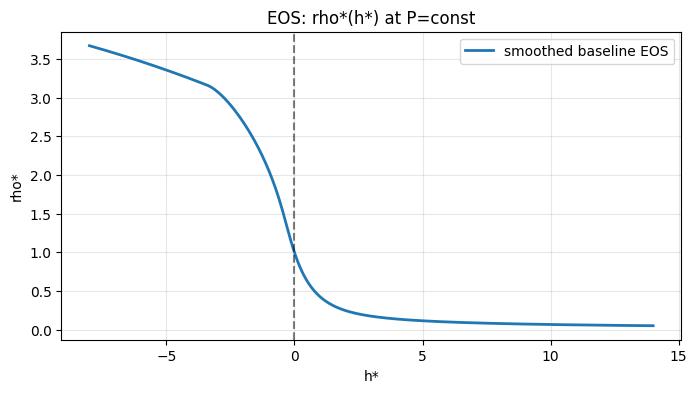

In [8]:
# eos = EOSStar.from_npz("eos_water_25MPa_smooth.npz")
eos = build_eos_star(
    fluid, pc,
    h_star_min=-8.0, h_star_max=14.0, n_grid=3200,
    smooth_left=True, H1=-3.4, rho_inf=5.0,
    save_raw_npz="eos_water_25MPa_raw.npz",
    save_smooth_npz="eos_water_25MPa_smooth.npz",
)

hs_plot = np.linspace(eos.h_star_min, eos.h_star_max, 500)
plt.figure(figsize=(8,4))
plt.plot(hs_plot, eos.rho_star(hs_plot), lw=2, label="smoothed baseline EOS")
plt.axvline(0.0, ls="--", c="k", alpha=0.5)
plt.xlabel("h*")
plt.ylabel("rho*")
plt.title("EOS: rho*(h*) at P=const")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 4) Steady-state

In [9]:

@dataclass
class SteadyState:
    N: int
    dz: float
    zc: np.ndarray
    zf: np.ndarray
    h_in_star: float
    h_star_c: np.ndarray
    rho_star_c: np.ndarray
    drho_dh_c: np.ndarray
    rho_in: float
    G_star: float
    rho_f: np.ndarray
    w_f: np.ndarray
    Ttrans_star: float
    w_max: float

def steady_state(NSPC: float, NTPC: float, N: int, eos: EOSStar) -> SteadyState:
    dz = 1.0 / N
    zc = (np.arange(N) + 0.5) * dz
    zf = np.arange(N + 1) * dz

    h_in_star = -float(NSPC)
    h_star_c = h_in_star + float(NTPC) * zc

    if (np.nanmin(h_star_c) < eos.h_star_min) or (np.nanmax(h_star_c) > eos.h_star_max):
        raise ValueError("h* leaves EOS table. Enlarge eos range.")

    rho_star_c = eos.rho_star(h_star_c)
    drho_dh_c  = eos.drho_dh(h_star_c)

    rho_in = float(eos.rho_star(h_in_star))
    G_star = rho_in

    rho_f = np.empty(N + 1)
    rho_f[0] = rho_in
    rho_f[1:] = rho_star_c

    w_f = G_star / rho_f
    Ttrans = float(np.sum(dz / w_f))
    w_max = float(np.max(w_f))

    return SteadyState(N, dz, zc, zf, h_in_star, h_star_c,
                      rho_star_c, drho_dh_c, rho_in, G_star,
                      rho_f, w_f, Ttrans, w_max)


## 5) Linear solver

In [10]:

@dataclass
class LinResult:
    mu_dom: complex
    z_dom: complex
    zR: float
    zI: float
    Ttrans_over_T: float

def build_AB(ss: SteadyState, Fr: float, Lambda: float, K_in: float, K_out: float,
             delta_scale: str = "1/dz"):
    N = ss.N
    dz = ss.dz
    Nh, Ng, Np = N, N+1, N
    M = Nh + Ng + Np

    def ih(i): return i
    def ig(j): return Nh + j
    def ip(i): return Nh + Ng + i

    A = np.zeros((M, M), dtype=float)
    B = np.zeros((M, M), dtype=float)

    # Mass
    for i in range(N):
        r = i
        B[r, ih(i)] = ss.drho_dh_c[i]
        A[r, ig(i)]   = +1.0/dz
        A[r, ig(i+1)] = -1.0/dz

    # Energy
    base_energy = N
    G0 = ss.G_star
    for i in range(N):
        r = base_energy + i
        B[r, ih(i)] = ss.rho_star_c[i] + ss.h_star_c[i] * ss.drho_dh_c[i]

        jR = i + 1
        A[r, ig(jR)] += -(ss.h_star_c[i]) / dz
        A[r, ih(i)]  += -(G0) / dz

        jL = i
        if i == 0:
            A[r, ig(jL)] += +(ss.h_in_star) / dz
        else:
            A[r, ig(jL)] += +(ss.h_star_c[i-1]) / dz
            A[r, ih(i-1)] += +(G0) / dz

    # Momentum
    base_mom = 2 * N
    rho_f = ss.rho_f
    drho_dh_f = np.zeros_like(rho_f)
    drho_dh_f[0] = 0.0
    drho_dh_f[1:] = ss.drho_dh_c

    def aG(j): return 2.0 * G0 / rho_f[j]
    def aH(j): return -(G0**2 / (rho_f[j]**2)) * drho_dh_f[j]

    def add_deltaQ_row(r, j_idx, mult):
        A[r, ig(j_idx)] += mult * aG(j_idx)
        if j_idx >= 1:
            A[r, ih(j_idx-1)] += mult * aH(j_idx)

    for j in range(Ng):
        r = base_mom + j
        B[r, ig(j)] = 1.0

        Cj = Lambda
        if j == 0:
            Cj = Lambda + (K_in/dz if delta_scale == "1/dz" else K_in)
        elif j == Ng - 1:
            Cj = Lambda + (K_out/dz if delta_scale == "1/dz" else K_out)

        if j == 0:
            add_deltaQ_row(r, 1, -1.0/dz)
            add_deltaQ_row(r, 0, +1.0/dz)
        else:
            add_deltaQ_row(r, j,   -1.0/dz)
            add_deltaQ_row(r, j-1, +1.0/dz)

        if j == 0:
            A[r, ip(0)] += -(2.0/dz)
        elif j == Ng - 1:
            A[r, ip(N-1)] += +(2.0/dz)
        else:
            A[r, ip(j)]   += -(1.0/dz)
            A[r, ip(j-1)] += +(1.0/dz)

        if j >= 1:
            A[r, ih(j-1)] += -(drho_dh_f[j] / Fr)

        A[r, ig(j)] += (-Cj) * aG(j)
        if j >= 1:
            A[r, ih(j-1)] += (-Cj) * aH(j)

    return A, B

def dominant_mode_time_discrete(A, B, dt_star: float, mu_abs_max: float = 1e6):
    RHS = B / dt_star
    LHS = (B / dt_star) - A

    mu = linalg.eigvals(RHS, LHS)
    mu = mu[np.isfinite(mu.real) & np.isfinite(mu.imag)]
    mu = mu[np.abs(mu) < mu_abs_max]
    if mu.size == 0:
        return complex(np.nan, np.nan), complex(np.nan, np.nan)

    z = np.log(mu) / dt_star
    k = int(np.argmax(z.real))
    return mu[k], z[k]

def stability_point(NSPC: float, NTPC: float, eos: EOSStar,
                    N_nodes: int, Fr: float, Lambda: float,
                    K_in: float, K_out: float,
                    Cmax: float,
                    zI_eps: float = 1e-2,
                    delta_scale: str = "1/dz") -> LinResult:
    ss = steady_state(NSPC, NTPC, N_nodes, eos)
    dt_star = Cmax * ss.dz / ss.w_max

    A, B = build_AB(ss, Fr=Fr, Lambda=Lambda, K_in=K_in, K_out=K_out, delta_scale=delta_scale)
    mu_dom, z_dom = dominant_mode_time_discrete(A, B, dt_star)

    zR = float(np.real(z_dom))
    zI = float(np.imag(z_dom))

    if abs(zI) < zI_eps or not np.isfinite(zI):
        ratio = np.nan
    else:
        ratio = float(ss.Ttrans_star * abs(zI) / (2.0 * math.pi))

    return LinResult(mu_dom=mu_dom, z_dom=z_dom, zR=zR, zI=zI, Ttrans_over_T=ratio)


## 6) Map sweep + plotting + boundary extraction
См. предыдущий python-скрипт: здесь оставлены те же ячейки для sweep/plots/contour extraction.

NSPC sweep:   0%|          | 0/41 [00:00<?, ?it/s]

C:\Users\Suchotin\AppData\Local\Temp\ipykernel_22760\1840291740.py:107: RuntimeWarning: divide by zero encountered in log
  z = np.log(mu) / dt_star
C:\Users\Suchotin\AppData\Local\Temp\ipykernel_22760\1840291740.py:107: RuntimeWarning: invalid value encountered in divide
  z = np.log(mu) / dt_star
NSPC sweep: 100%|██████████| 41/41 [00:22<00:00,  1.79it/s]


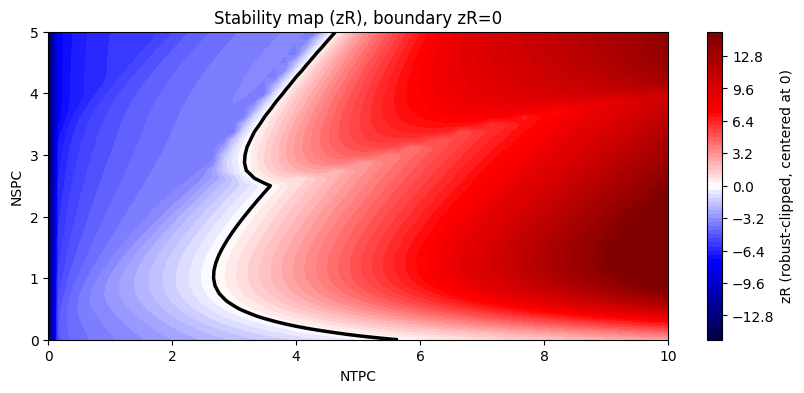

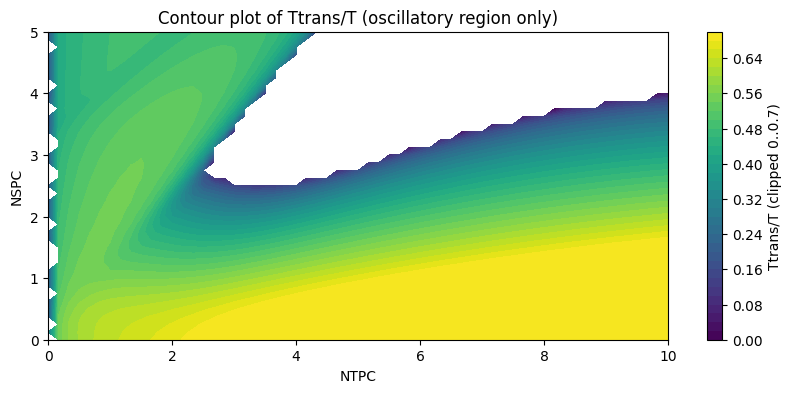

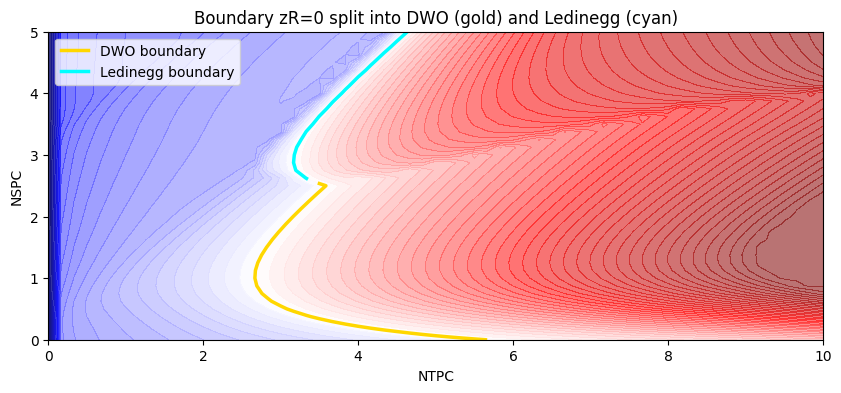

Saved: maps_water_25MPa_baseline.npz


In [11]:

# --- Config (Fig.2-like defaults, adjust if needed) ---
N_nodes = 48
Fr = 0.03
Lambda = 7.0
K_in = 20.0
K_out = 20.0
Cmax = 0.9

def compute_maps(NSPC_grid, NTPC_grid,
                 eos: EOSStar,
                 N_nodes: int, Fr: float, Lambda: float, K_in: float, K_out: float,
                 Cmax: float, zI_eps: float = 1e-2,
                 delta_scale: str = "1/dz"):
    zR_map = np.full((len(NSPC_grid), len(NTPC_grid)), np.nan, dtype=float)
    zI_map = np.full_like(zR_map, np.nan)
    ratio_map = np.full_like(zR_map, np.nan)

    for iy, NSPC in enumerate(tqdm(NSPC_grid, desc="NSPC sweep")):
        for ix, NTPC in enumerate(NTPC_grid):
            try:
                res = stability_point(float(NSPC), float(NTPC),
                                      eos=eos, N_nodes=N_nodes,
                                      Fr=Fr, Lambda=Lambda, K_in=K_in, K_out=K_out,
                                      Cmax=Cmax, zI_eps=zI_eps, delta_scale=delta_scale)
                zR_map[iy, ix] = res.zR
                zI_map[iy, ix] = res.zI
                ratio_map[iy, ix] = res.Ttrans_over_T
            except Exception:
                continue
    return zR_map, zI_map, ratio_map

NSPC_grid = np.linspace(0.0, 5.0, 41)
NTPC_grid = np.linspace(0.0, 10.0, 61)

zR_map, zI_map, ratio_map = compute_maps(
    NSPC_grid, NTPC_grid,
    eos=eos,
    N_nodes=N_nodes, Fr=Fr, Lambda=Lambda, K_in=K_in, K_out=K_out,
    Cmax=Cmax, zI_eps=1e-2, delta_scale="1/dz"
)

X, Y = np.meshgrid(NTPC_grid, NSPC_grid)

# --- zR plot (robust) ---
Z = zR_map.copy()
lo, hi = np.nanpercentile(Z, [2, 98])
m = max(abs(lo), abs(hi))
Zc = np.clip(Z, -m, m)
norm = colors.TwoSlopeNorm(vmin=-m, vcenter=0.0, vmax=m)

plt.figure(figsize=(10,4))
cf = plt.contourf(X, Y, Zc, levels=80, norm=norm, cmap="seismic")
plt.colorbar(cf, label="zR (robust-clipped, centered at 0)")
plt.contour(X, Y, Z, levels=[0.0], colors="k", linewidths=2.5)
plt.xlabel("NTPC"); plt.ylabel("NSPC")
plt.title("Stability map (zR), boundary zR=0")
plt.show()

# --- Ttrans/T (osc only) ---
zI_eps = 1e-2
R = ratio_map.copy()
R[np.abs(zI_map) < zI_eps] = np.nan
R = np.clip(R, 0.0, 0.7)

plt.figure(figsize=(10,4))
cf = plt.contourf(X, Y, R, levels=np.linspace(0, 0.7, 36), cmap="viridis")
plt.colorbar(cf, label="Ttrans/T (clipped 0..0.7)")
plt.xlabel("NTPC"); plt.ylabel("NSPC")
plt.title("Contour plot of Ttrans/T (oscillatory region only)")
plt.show()

# --- boundary extraction ---
def _nearest_on_grid(x, grid):
    return int(np.clip(np.argmin(np.abs(grid - x)), 0, len(grid)-1))

def extract_boundaries_from_contour(NTPC_grid, NSPC_grid, zR_map, zI_map, zI_eps=1e-2):
    X, Y = np.meshgrid(NTPC_grid, NSPC_grid)
    fig = plt.figure()
    CS = plt.contour(X, Y, zR_map, levels=[0.0])
    plt.close(fig)

    segs = []
    if hasattr(CS, "allsegs") and len(CS.allsegs) > 0 and len(CS.allsegs[0]) > 0:
        segs = CS.allsegs[0]
    elif hasattr(CS, "collections"):
        for col in CS.collections:
            for p in col.get_paths():
                segs.append(p.vertices)

    if not segs:
        return [], []

    dwo, led = [], []
    for v in segs:
        if v.shape[0] < 5:
            continue

        zi_abs = []
        for x, y in v:
            ix = _nearest_on_grid(x, NTPC_grid)
            iy = _nearest_on_grid(y, NSPC_grid)
            val = zI_map[iy, ix]
            zi_abs.append(abs(val) if np.isfinite(val) else 0.0)

        osc = np.array(zi_abs) > zI_eps

        start = 0
        while start < len(v):
            val = osc[start]
            end = start + 1
            while end < len(v) and osc[end] == val:
                end += 1
            seg = v[start:end]
            if seg.shape[0] >= 5:
                (dwo if val else led).append(seg)
            start = end

    return dwo, led

dwo_segs, led_segs = extract_boundaries_from_contour(NTPC_grid, NSPC_grid, zR_map, zI_map, zI_eps=zI_eps)

plt.figure(figsize=(10,4))
plt.contourf(X, Y, Zc, levels=80, norm=norm, cmap="seismic", alpha=0.55)

for i, seg in enumerate(dwo_segs):
    plt.plot(seg[:,0], seg[:,1], lw=2.5, color="gold", label="DWO boundary" if i == 0 else None)
for i, seg in enumerate(led_segs):
    plt.plot(seg[:,0], seg[:,1], lw=2.5, color="cyan", label="Ledinegg boundary" if i == 0 else None)

plt.xlabel("NTPC"); plt.ylabel("NSPC")
plt.title("Boundary zR=0 split into DWO (gold) and Ledinegg (cyan)")
plt.legend(loc="upper left")
plt.show()

# --- save ---
out_path = "maps_water_25MPa_baseline.npz"
np.savez(
    out_path,
    NSPC_grid=NSPC_grid, NTPC_grid=NTPC_grid,
    zR_map=zR_map, zI_map=zI_map, ratio_map=ratio_map,
    N_nodes=N_nodes, Fr=Fr, Lambda=Lambda, K_in=K_in, K_out=K_out, Cmax=Cmax
)
print("Saved:", out_path)
